# Exercise 4

Author: Kim Hummel 

Date: 9/19/26

Objective: connect database to SQL/python and run SQL commands. 

## Fixes to environment issues.  

When I tried to follow the steps from the book I ran into quite a few issues with my environment. I had to run the following lines of code in the terminal, and then restart the kernals by pressing the restart button on the top, next to the tool bar. 

uv pip install pandas matplotlib sqlalchemy ipykernel

uv add psycopg2-binary 

uv add jupysql

## Import packages 

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sqlalchemy
import psycopg2

from sqlalchemy import create_engine

## Connect to database 

The first cell connect to postgreSQL. The second connects to the "world" database.

https://www.youtube.com/watch?v=M2NzvnfS-hI&t=211s
This video doesn't follow exactly the same steps as the book but it did help me understand what was going on and where I needed to go to find the information to connect to the world database. 

In [2]:
# Connect to postgreSQL
cnxn_string = ("postgresql+psycopg2://{username}:{pswd}"
     "@{host}:{port}/{database}")
print(cnxn_string)

postgresql+psycopg2://{username}:{pswd}@{host}:{port}/{database}


In [3]:
# Create engine/ connect to database
engine = create_engine(cnxn_string.format(
    username="postgres",
    pswd="KarlDouglas93",
    host="localhost",
    port=5432,
    database="World"))

## Create Query 

Created the query and used code to run it. I printed the table as well to make sure I had gotten the correct information and that everything ran as it was supposed to. 

In [4]:
# create the query 
query = """
SELECT country.name, COUNT(language) AS total_languages_spoken
FROM country
JOIN countrylanguage ON country.code = countrylanguage.countrycode
WHERE countrylanguage.IsOfficial = 'T'
GROUP BY country.name
HAVING COUNT(language) >2
ORDER BY total_languages_spoken DESC
"""
# run the query and create the new table/data set
more_languages = pd.read_sql_query(query, engine)
print(more_languages)

                                                name  total_languages_spoken
0  Switzerland                                   ...                       4
1  South Africa                                  ...                       4
2  Vanuatu                                       ...                       3
3  Belgium                                       ...                       3
4  Luxembourg                                    ...                       3
5  Peru                                          ...                       3
6  Bolivia                                       ...                       3
7  Singapore                                     ...                       3


## Create Graph 

Created table from queried information that mirrors the one in the directions. 

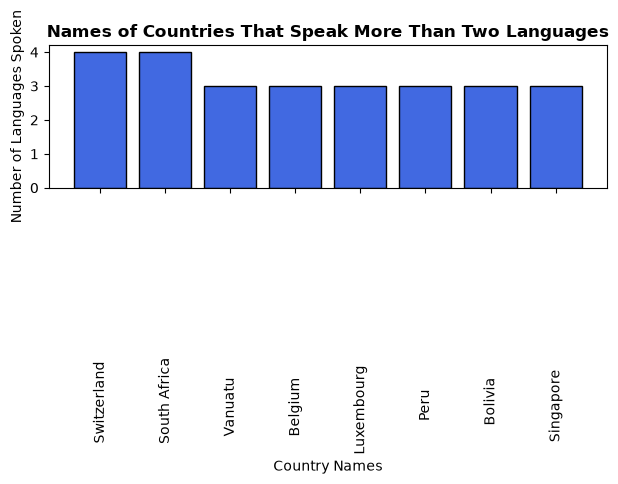

In [5]:
# create the bar graph
plt.figure()
plt.bar(more_languages['name'], more_languages['total_languages_spoken'], color='royalblue', edgecolor='black')

# Customize the graph
plt.title('Names of Countries That Speak More Than Two Languages', fontsize=12, fontweight='bold')
plt.xlabel('Country Names', fontsize=10)
plt.ylabel('Number of Languages Spoken', fontsize=10)
plt.xticks(rotation=90)  # Rotate labels if they overlap
plt.tight_layout() 

# Display chart and close connection
plt.show()


## Custom Query 

I didn't think we had to do this because it wasn't in the exercise markdown. But when I look at other people who have submitted their work they have a custom query so I'm adding one even though I already submitted my response on canva. 

I found the number of cities with a population over 1,000,000 per continent. 

In [6]:
query2 = """
SELECT country.continent, COUNT(city.population) AS big_cities
FROM country
JOIN city on country.code = city.countrycode
WHERE city.population > 1000000
GROUP BY country.continent
Order by big_cities DESC
"""

# run the query and create the new table/data set
big_cities_per_continent = pd.read_sql_query(query2, engine)
print(big_cities_per_continent)

                                           continent  big_cities
0  Asia                                          ...         125
1  Europe                                        ...          36
2  South America                                 ...          27
3  Africa                                        ...          23
4  North America                                 ...          22
5  Oceania                                       ...           4


## Bar Graph of Custom Query
Now we create a bar graph for the custom query. 

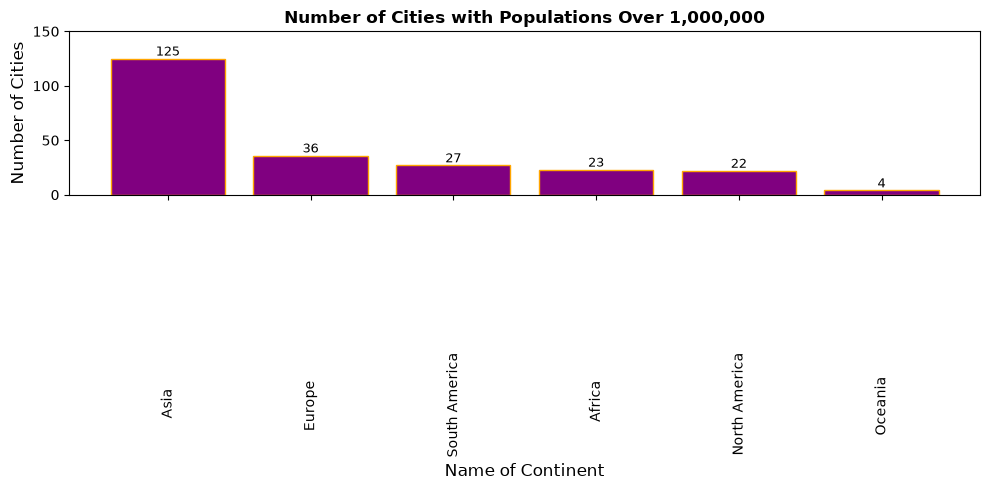

In [8]:
# create the bar graph
plt.figure(figsize=(10, 5))
bars = plt.bar(big_cities_per_continent['continent'], big_cities_per_continent['big_cities'], color='purple', edgecolor='orange')

# Add the number on top of each bar
plt.bar_label(bars, fontsize=9)

# Customize the graph
plt.title('Number of Cities with Populations Over 1,000,000', fontsize=12, fontweight='bold')
plt.xlabel('Name of Continent', fontsize=12)
plt.ylabel('Number of Cities', fontsize=12)
plt.xticks(rotation=90, va='top')
plt.tight_layout() 

# Create Header so the numbers don't get cut off
plt.ylim(0, big_cities_per_continent['big_cities'].max() * 1.2)

# Display chart and close connection
plt.show()